# NSU BDA. 2024 Accidents
Соревнование для студенттов курса АБМД, ФИТ НГУ 2024

Студент: Митюшин Владимир 24221

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

Загрузим данные

In [35]:
X_train = pd.read_csv('X_train.csv', index_col=0)
X_testFinal = pd.read_csv('X_test.csv', index_col=0)
Y_train = pd.read_csv('Y_train.csv', index_col=0)

Выведем информацию по датасетам

In [36]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499056 entries, 241270 to 121958
Data columns (total 35 columns):
 #   Column                                   Non-Null Count   Dtype 
---  ------                                   --------------   ----- 
 0   accident_index                           499056 non-null  object
 1   vehicle_reference                        499056 non-null  int64 
 2   casualty_class                           499056 non-null  int64 
 3   sex_of_casualty                          499056 non-null  int64 
 4   age_of_casualty                          499056 non-null  int64 
 5   age_band_of_casualty                     499056 non-null  int64 
 6   pedestrian_location                      499056 non-null  int64 
 7   pedestrian_movement                      499056 non-null  int64 
 8   car_passenger                            499056 non-null  int64 
 9   bus_or_coach_passenger                   499056 non-null  int64 
 10  pedestrian_road_maintenance_worker       499

In [37]:
Y_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499056 entries, 241270 to 121958
Data columns (total 1 columns):
 #   Column             Non-Null Count   Dtype
---  ------             --------------   -----
 0   casualty_severity  499056 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


Посмотрим более подробно на целевой признак

In [38]:
print("min: ", Y_train['casualty_severity'].min())
print("max: ", Y_train['casualty_severity'].max())
print("unique: ", Y_train['casualty_severity'].unique())

min:  1
max:  3
unique:  [3 2 1]


### Исходя из возможных значений целевого признака понимаем, что имеем задачу классификации

## Очистка и подготовка данных

In [39]:
X_train.describe()

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,vehicle_left_hand_drive,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000
mean,1.457009,1.472198,1.366891,36.823471,6.312548,0.758696,0.613450,0.231964,0.050407,0.025949,7.621940,1.067680,1.586858,9.251459,19.397414,1.278187,1233.934146,6.178537,28.349796,4.144018,801.286110,5.233060,37.549017,3.777957,1.678210,2.994840,223.466781,0.321896,1.104309,2.056154,1.638289,1.371584
std,2.323518,0.725208,0.529874,19.526246,2.453729,2.144590,1.963437,0.627427,0.436082,0.232426,10.532901,0.919608,1.424478,11.366400,21.870117,1.461020,1294.323320,6.515864,24.402768,1.470346,1593.954718,1.672408,14.742382,11.998430,2.516433,2.758235,935.872042,1.637604,2.372924,1.734888,1.790234,0.930508
min,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,1.000000,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,1.000000,1.000000,1.000000,22.000000,5.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,8.000000,9.000000,1.000000,108.000000,0.000000,5.000000,3.000000,0.000000,6.000000,30.000000,0.000000,-1.000000,0.000000,-1.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,34.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,1.000000,9.000000,18.000000,1.000000,1299.000000,5.000000,23.000000,4.000000,38.000000,6.000000,30.000000,1.000000,2.000000,3.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,50.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,2.000000,9.000000,18.000000,1.000000,1796.000000,11.000000,45.000000,6.000000,563.000000,6.000000,50.000000,3.000000,4.000000,6.000000,0.000000,0.000000,0.000000,4.000000,1.000000,2.000000
max,999.000000,3.000000,9.000000,102.000000,11.000000,10.000000,9.000000,9.000000,9.000000,2.000000,99.000000,3.000000,5.000000,99.000000,99.000000,9.000000,29980.000000,122.000000,99.000000,6.000000,9176.000000,9.000000,70.000000,99.000000,9.000000,6.000000,9999.000000,9.000000,9.000000,7.000000,9.000000,9.000000


In [40]:
df = X_train.copy()
df = df[df.select_dtypes('number').columns].replace(-1, np.nan)
df.fillna(df.median(), inplace=True)
df[X_train.select_dtypes('O').columns] = X_train.select_dtypes('O')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499056 entries, 241270 to 121958
Data columns (total 35 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   vehicle_reference                        499056 non-null  int64  
 1   casualty_class                           499056 non-null  int64  
 2   sex_of_casualty                          499056 non-null  float64
 3   age_of_casualty                          499056 non-null  float64
 4   age_band_of_casualty                     499056 non-null  float64
 5   pedestrian_location                      499056 non-null  float64
 6   pedestrian_movement                      499056 non-null  float64
 7   car_passenger                            499056 non-null  float64
 8   bus_or_coach_passenger                   499056 non-null  float64
 9   pedestrian_road_maintenance_worker       499056 non-null  float64
 10  casualty_type                   

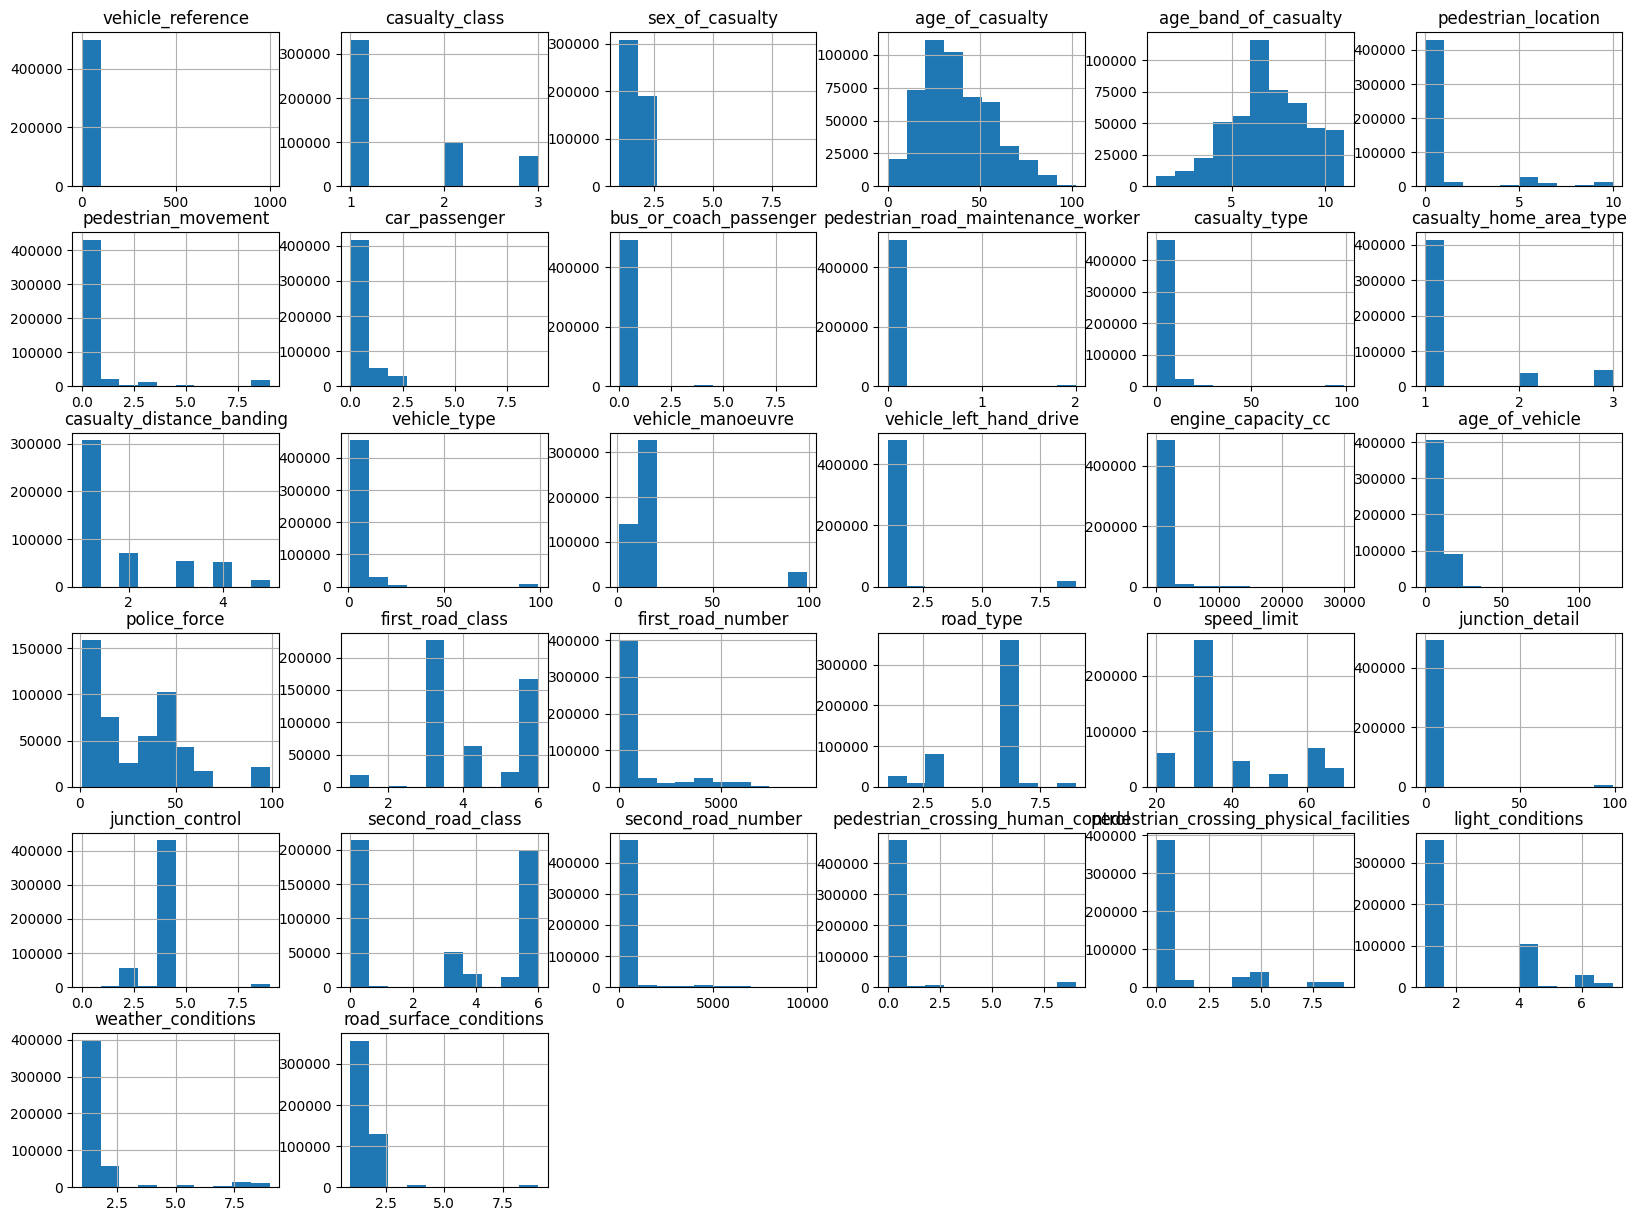

In [41]:
df.hist(figsize=(20, 15));

In [42]:
df[df.select_dtypes('number').columns].corr().style.background_gradient(cmap='coolwarm')

,vehicle_reference,casualty_class,sex_of_casualty,age_of_casualty,age_band_of_casualty,pedestrian_location,pedestrian_movement,car_passenger,bus_or_coach_passenger,pedestrian_road_maintenance_worker,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_type,vehicle_manoeuvre,vehicle_left_hand_drive,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,junction_control,second_road_class,second_road_number,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
vehicle_reference,1.000000,-0.064538,0.005444,0.009645,0.011815,-0.064518,-0.056105,0.007240,-0.008421,-0.021266,0.016864,0.008398,0.012283,-0.010700,-0.048798,-0.034604,-0.006543,-0.010579,0.013586,-0.023168,0.003192,-0.021420,0.023859,-0.020136,-0.013776,0.008945,0.006511,-0.029742,-0.025682,-0.016973,-0.011585,-0.014558
casualty_class,-0.064538,1.000000,0.158024,-0.102583,-0.156782,0.745240,0.658191,0.273586,0.084883,0.250650,-0.212637,-0.071335,-0.107581,0.105693,-0.068390,0.020863,0.151720,0.002173,-0.024235,0.106220,-0.013121,0.057076,-0.149814,-0.024211,-0.019769,-0.031808,-0.010291,-0.022224,0.050846,0.015351,0.013415,-0.014705
sex_of_casualty,0.005444,0.158024,1.000000,0.043442,0.034744,0.032708,0.034298,0.143394,0.069953,0.007879,-0.001675,0.036267,-0.022757,0.017392,-0.074876,-0.001440,0.043844,-0.004481,0.040391,0.001798,0.003214,-0.006407,0.022358,-0.026034,-0.021269,-0.005763,0.010390,-0.034498,-0.019042,-0.057026,0.000788,-0.008149
age_of_casualty,0.009645,-0.102583,0.043442,1.000000,0.975326,-0.019550,-0.005622,-0.162660,0.044678,-0.015685,0.002023,0.081148,0.052224,-0.005223,-0.050684,-0.013951,0.084249,0.003123,0.052034,-0.051179,0.008432,-0.011979,0.059664,-0.018585,-0.002609,0.004161,0.012438,-0.025855,-0.031854,-0.093820,-0.019637,-0.019665
age_band_of_casualty,0.011815,-0.156782,0.034744,0.975326,1.000000,-0.049170,-0.027791,-0.198602,0.031328,-0.021764,0.008778,0.070812,0.066755,-0.011340,-0.030648,-0.004171,0.071329,-0.002397,0.039708,-0.067519,0.009928,-0.020998,0.062205,-0.008341,-0.000769,0.008665,0.014208,-0.012505,-0.022110,-0.074726,-0.014623,-0.011524
pedestrian_location,-0.064518,0.745240,0.032708,-0.019550,-0.049170,1.000000,0.831278,-0.134375,-0.041261,0.294266,-0.256031,-0.051122,-0.123288,0.088142,-0.032260,0.019347,0.069436,-0.010496,-0.028429,0.163238,-0.030947,0.086720,-0.188363,-0.003057,0.031255,-0.026420,-0.025970,-0.001662,0.013509,-0.006273,0.027217,-0.009068
pedestrian_movement,-0.056105,0.658191,0.034298,-0.005622,-0.027791,0.831278,1.000000,-0.118674,-0.036440,0.251931,-0.226118,-0.043893,-0.104581,0.097828,-0.012204,0.039668,0.061227,-0.008268,-0.035841,0.135872,-0.026098,0.078147,-0.167575,0.008312,0.023642,-0.029448,-0.024075,0.017522,0.034873,-0.003072,0.038058,0.000507
car_passenger,0.007240,0.273586,0.143394,-0.162660,-0.198602,-0.134375,-0.118674,1.000000,-0.040891,-0.045191,0.052190,-0.006501,0.051298,-0.006217,-0.005337,0.072033,0.019976,0.022815,0.013997,-0.048147,0.007253,-0.023560,0.090867,-0.005768,-0.008207,-0.031748,0.010469,0.006740,-0.016295,0.058437,0.002925,0.023042
bus_or_coach_passenger,-0.008421,0.084883,0.069953,0.044678,0.031328,-0.041261,-0.036440,-0.040891,1.000000,-0.013876,0.037451,-0.028476,-0.036249,0.017949,-0.026821,-0.009715,0.413479,-0.013807,-0.036505,-0.019120,-0.000726,-0.002673,-0.051374,-0.001925,-0.026357,0.006113,-0.001878,0.003192,0.026206,-0.031411,0.004593,0.001325
pedestrian_road_maintenance_worker,-0.021266,0.250650,0.007879,-0.015685,-0.021764,0.294266,0.251931,-0.045191,-0.013876,1.000000,-0.086109,-0.027672,-0.045019,0.029303,-0.031283,-0.021629,0.018826,0.000667,-0.011921,0.059882,0.005919,0.024880,-0.060051,-0.012023,-0.007121,-0.003847,0.001231,-0.014161,0.006099,-0.000253,0.009328,-0.013481


In [43]:
df = df.drop(columns='accident_index')
df = df.drop(columns=['age_of_casualty', 'pedestrian_movement', 'second_road_number', 'junction_control', 'bus_or_coach_passenger', 'pedestrian_road_maintenance_worker', 'vehicle_left_hand_drive', 'vehicle_type'])

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
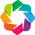

BokehModel(combine_events=True, render_bundle={'docs_json': {'9ba7ef68-4bd2-48ed-b0b4-90f492e5dc13': {'version…

In [44]:
import holoviews as hv
from holoviews import dim
from holoviews import opts
hv.extension('bokeh')


def f(x):
    return hv.BoxWhisker(df[x]).opts(height=120, responsive=True, toolbar='above', invert_axes=True, tools=['hover'])

hv.DynamicMap(f, kdims=['x']).redim.values(x=df.select_dtypes('number').columns)

In [45]:
df.drop(df[df.vehicle_reference > 20].index, inplace=True)
df['sex_of_casualty'].replace(9, -1) # df['sex_of_casualty'].median()
df['car_passenger'].replace(9, -1) # df['car_passenger'].median()
df['casualty_type'].replace([3, 4, 5, 22, 23, 97, 103, 104, 105, 106], 2).replace([20, 21, 98, 113], 19)

Id
241270     9.0
164802     2.0
201250     9.0
86459      9.0
304174     9.0
          ... 
644167     9.0
259178     0.0
365838    19.0
131932     9.0
121958     1.0
Name: casualty_type, Length: 499056, dtype: float64

### Посмотрим на категориальные признаки

In [46]:
df.describe(include='O')

,generic_make_model,local_authority_highway
count,499056,499056
unique,1130,210
top,-1,E10000016
freq,132305,16811


In [47]:
df['generic_make_model'] = df['generic_make_model'].str.split(n=1).str[0].str.upper()
display(df['generic_make_model'].value_counts(dropna=False))

generic_make_model
-1            132305
FORD           44024
VAUXHALL       36320
VOLKSWAGEN     28373
HONDA          25974
               ...  
LML                8
CASE               7
OPEL               6
PROTON             6
VALTRA             5
Name: count, Length: 114, dtype: int64

In [48]:
display(df['local_authority_highway'].value_counts(dropna=False))

local_authority_highway
E10000016    16811
E10000030    12860
E10000012    11381
E08000025    11213
E10000017    10866
             ...  
EHEATHROW       98
S12000013       76
S12000023       63
S12000027       62
E06000053        6
Name: count, Length: 210, dtype: int64

In [49]:
one_hot = pd.get_dummies(df.select_dtypes('O'), prefix=df.select_dtypes('O').columns, dtype=bool)
df = pd.concat([one_hot, df.select_dtypes('number'), df.select_dtypes('bool')], axis=1)

df.describe()

,vehicle_reference,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_location,car_passenger,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_manoeuvre,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000,499056.000000
mean,1.457009,1.472198,1.381855,6.465339,0.758708,0.236354,7.622942,1.265217,1.786114,19.514714,1597.470502,8.300279,28.349796,4.144018,801.286110,5.233060,37.553862,3.777977,2.998623,0.329558,1.111891,2.056194,1.638333,1.381462
std,2.323518,0.725208,0.489523,2.198272,2.144583,0.622268,10.532556,0.620358,1.164925,21.811275,1091.114485,5.156388,24.402768,1.470346,1593.954718,1.672408,14.734804,11.998424,2.755495,1.633736,2.367780,1.734841,1.790194,0.915777
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,0.000000,1.000000,1.000000,0.000000,1.000000,20.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,5.000000,0.000000,0.000000,1.000000,1.000000,1.000000,9.000000,1248.000000,5.000000,5.000000,3.000000,0.000000,6.000000,30.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,6.000000,0.000000,0.000000,9.000000,1.000000,1.000000,18.000000,1499.000000,8.000000,23.000000,4.000000,38.000000,6.000000,30.000000,1.000000,3.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,2.000000,2.000000,2.000000,8.000000,0.000000,0.000000,9.000000,1.000000,2.000000,18.000000,1796.000000,11.000000,45.000000,6.000000,563.000000,6.000000,50.000000,3.000000,6.000000,0.000000,0.000000,4.000000,1.000000,2.000000
max,999.000000,3.000000,9.000000,11.000000,10.000000,9.000000,99.000000,3.000000,5.000000,99.000000,29980.000000,122.000000,99.000000,6.000000,9176.000000,9.000000,70.000000,99.000000,6.000000,9.000000,9.000000,7.000000,9.000000,9.000000


In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499056 entries, 241270 to 121958
Columns: 348 entries, generic_make_model_-1 to road_surface_conditions
dtypes: bool(324), float64(18), int64(6)
memory usage: 265.5 MB


## Перейдём к обучению

In [51]:
X_testFinal = X_testFinal.reindex(df.columns, axis=1)
X_testFinal.fillna(0, inplace=True)
X_testFinal.describe()

,generic_make_model_-1,generic_make_model_ABARTH,generic_make_model_AJS,generic_make_model_ALEXANDER,generic_make_model_ALFA,generic_make_model_APRILIA,generic_make_model_AUDI,generic_make_model_BENELLI,generic_make_model_BENTLEY,generic_make_model_BMW,generic_make_model_BYD,generic_make_model_CAETANO,generic_make_model_CASE,generic_make_model_CHEVROLET,generic_make_model_CHRYSLER,generic_make_model_CITROEN,generic_make_model_CLAAS,generic_make_model_CUPRA,generic_make_model_DACIA,generic_make_model_DAEWOO,generic_make_model_DAF,generic_make_model_DAIHATSU,generic_make_model_DENNIS,generic_make_model_DERBI,generic_make_model_DODGE,generic_make_model_DS,generic_make_model_DUCATI,generic_make_model_FENDT,generic_make_model_FIAT,generic_make_model_FORD,generic_make_model_GILERA,generic_make_model_HARLEY-DAVIDSON,generic_make_model_HONDA,generic_make_model_HUSQVARNA,generic_make_model_HYOSUNG,generic_make_model_HYUNDAI,generic_make_model_INFINITI,generic_make_model_ISUZU,generic_make_model_IVECO,generic_make_model_JAGUAR,...,local_authority_highway_W06000008,local_authority_highway_W06000009,local_authority_highway_W06000010,local_authority_highway_W06000011,local_authority_highway_W06000012,local_authority_highway_W06000013,local_authority_highway_W06000014,local_authority_highway_W06000015,local_authority_highway_W06000016,local_authority_highway_W06000018,local_authority_highway_W06000019,local_authority_highway_W06000020,local_authority_highway_W06000021,local_authority_highway_W06000022,local_authority_highway_W06000023,local_authority_highway_W06000024,vehicle_reference,casualty_class,sex_of_casualty,age_band_of_casualty,pedestrian_location,car_passenger,casualty_type,casualty_home_area_type,casualty_distance_banding,vehicle_manoeuvre,engine_capacity_cc,age_of_vehicle,police_force,first_road_class,first_road_number,road_type,speed_limit,junction_detail,second_road_class,pedestrian_crossing_human_control,pedestrian_crossing_physical_facilities,light_conditions,weather_conditions,road_surface_conditions
count,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,...,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.0,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.00000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000,166352.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.457271,1.470322,1.366873,6.305587,0.745834,0.232699,7.616548,1.068289,1.587892,19.306639,1242.074330,6.18414,28.323892,4.149598,796.766651,5.238975,37.547730,3.767667,3.008446,0.313859,1.095220,2.051848,1.634257,1.371369
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.636512,0.722688,0.532466,2.455111,2.123633,0.626563,10.439010,0.917274,1.424338,21.728723,1317.162953,6.47909,24.336775,1.469986,1585.718521,1.665436,14.710353,11.917428,2.759564,1.618394,2.362987,1.732798,1.787258,0.933177
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

In [53]:
x_train, x_test, y_train, y_test = train_test_split(df, Y_train, test_size=0.1, random_state=42) # df \ X_train
print(x_train.shape, y_train.shape)

(449150, 348) (449150, 1)


In [55]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [56]:
print(x_train.shape, X_testFinal.shape)

(449150, 348) (166352, 348)


In [57]:
from sklearn.neighbors import KNeighborsClassifier
knn_model_5 = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

In [58]:
knn_model_5.fit(x_train, y_train.values.ravel())

KNeighborsClassifier(n_jobs=-1)

In [59]:
y_predicted_5 = knn_model_5.predict(x_test)

C:\Users\Horsen\AppData\Roaming\Python\Python39\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] Не удается найти указанный файл
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\Horsen\AppData\Roaming\Python\Python39\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Program Files\Python39\lib\subprocess.py", line 505, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python39\lib\subprocess.py", line 951, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python39\lib\subprocess.py", line 1420, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


In [60]:
# f1_3 = f1_score(y_test, y_predicted_3, average='micro')
# print(f1_3)

f1_5 = f1_score(y_test, y_predicted_5, average='macro')
print(f1_5)

0.3666841116702084


In [61]:
# y_predicted_Final = knn_model_5.predict(X_testFinal)

In [62]:
# print(y_predicted_Final)

In [63]:
# my_file = open("knn_0.36.csv", "w+")

# my_file.write("Id,casualty_severity\n")
# my_i = 0
# for i, row in X_testFinal.iterrows():
#     my_file.write(f"{i}, {y_predicted_Final[my_i]}\n")
#     my_i = my_i+1
# my_file.close()